# **Text Statistics**

Statistics in the context of text processing refers to the quantitative analysis of text data. It involves using various statistical techniques to analyze and summarize the characteristics of a text corpus, such as word frequency, sentence length, readability, and other linguistic features.

In this session, we will explore some common text statistics techniques and how to apply them using Python.
We will reuse the Alice in Wonderland text as our sample data for analysis.

In [1]:
## No need to concern about this function
## This is helper for getting the text of Alice in Wonderland from Project Gutenberg

import requests
from functools import cache
import pandas as pd

ALICE_URL = "https://www.gutenberg.org/files/11/11-0.txt"


@cache
def get_alice() -> pd.DataFrame:
    # fetch the book from the URL
    book = requests.get(ALICE_URL).text

    # remove the table of contents
    chapters = book.split("CHAPTER ")[13:]

    # content format is [CHAPTER NUMBER].\n[TITLE]\n\n\\n[CONTENT]
    records = []
    for chapter in chapters:
        number, title, content = chapter.split("\n", 2)
        records.append((number.strip(), title.strip(), content.strip()))

    return pd.DataFrame(records, columns=["chapter", "title", "content"])


We will use the library [`scikit-learn`](https://scikit-learn.org/stable/) to help us with some of the text statistics calculations, such as term frequency and inverse document frequency. We will also use `spacy` for natural language processing tasks.

scikit-learn is a powerful machine learning library in Python that provides tools for data analysis and modeling. Besides machine learning, it also offers utilities for feature engineering that will be useful for our text statistics analysis.

In [2]:
MODEL_NAME = "en_core_web_sm"

!pip install spacy scikit-learn
!python -m spacy download $MODEL_NAME

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
import spacy

nlp = spacy.load(MODEL_NAME)

## Term Frequency

Term Frequency (TF) is a measure of how frequently a term (word) appears in a document. It is calculated as the number of times a term appears in a document divided by the total number of terms in the document. TF is often used in text mining and information retrieval to evaluate the importance of a term within a document.

In this section, we will calculate the term frequency of words in the Alice in Wonderland text using Python.

In [4]:
alice = get_alice()
contents = alice["content"].tolist()

Python provides built-in libraries such as [`collections`](https://docs.python.org/3/library/collections.html) that can help us in this task. We will use the `Counter` class from the `collections` module to count the frequency of each word in the text.

`Counter` is an implementation of dictionary that is specifically designed for counting. It provides a convenient way to count the occurrences of each word in the text and can be easily used to calculate term frequency. As it is a subclass of `dict`, we can use all the standard dictionary methods with additional functionality related to counting.

In [5]:
from collections import Counter

chapter_1 = contents[0]
# split the chapter into words by whitespace
words = chapter_1.split()
# count the frequency of each word
word_counts = Counter(words)

word_counts.most_common(10)

[('the', 87),
 ('she', 73),
 ('to', 71),
 ('and', 56),
 ('a', 52),
 ('was', 51),
 ('of', 41),
 ('it', 41),
 ('*', 40),
 ('her', 24)]

For advanced text processing and to handle larger corpora, we can also use `scikit-learn`'s `CountVectorizer` which provides a more efficient way to compute term frequency across multiple documents.

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(contents)

tf = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tf

,11,_alice,_all,_all_,_and,_are_,_at,_before,_beg_,_began_,...,yet,you,you_,young,your,yours,yourself,youth,zealand,zigzag
0,0,0,0,0,0,0,0,0,0,0,...,0,19,0,0,1,0,0,0,1,0
1,0,1,0,0,0,0,0,0,0,0,...,1,26,0,0,3,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,32,0,1,7,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,4,17,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,5,46,0,1,8,0,2,6,0,1
5,0,0,0,0,0,1,0,0,0,0,...,1,38,0,0,3,0,1,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,3,53,0,1,1,0,1,0,0,0
7,0,0,0,0,0,1,0,0,0,0,...,1,22,0,0,5,0,0,0,0,0
8,0,0,0,0,1,1,1,0,0,0,...,2,41,0,2,8,2,3,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,56,0,0,0,0,0,0,0,0


Now we obtain the count of each term in the Alice in Wonderland text and create a DataFrame to display the term frequencies.

We then can analyze the term frequencies to identify the most common words in the text, which can provide insights into the themes and topics of the story.

In [7]:
freq = tf.sum().sort_values(ascending=False)
freq.head(10)

the      1637
and       869
to        729
it        592
she       549
of        514
said      460
you       396
alice     395
in        366
dtype: int64

From the term frequency analysis, we can see that the most common words in the Alice in Wonderland text are "the", "and", "to", "of", and "a". These are common stop words in English, which are often filtered out in text analysis to focus on more meaningful words. However, in this case, they provide insight into the structure of the language used in the story.

Now lets do stop word removal and lemmatization and see the most common words again.

In [8]:
def clean(text):
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop and token.is_alpha and not token.is_space
    ]
    return " ".join(tokens)

alice["cleaned_content"] = alice["content"].apply(clean)

In [9]:
cleaned_contents = alice["cleaned_content"].tolist()

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(cleaned_contents)
tf_cleaned = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

freq_cleaned = tf_cleaned.sum().sort_values(ascending=False)
freq_cleaned.head(10)

say       481
alice     395
think     134
go        129
little    127
know      107
look      106
begin      93
like       92
come       91
dtype: int64

Lets say we want to change the scope to the each chapter instead of the whole book, we can do that by applying the same process to each chapter separately. This way, we can analyze the term frequency for each chapter and see how the themes and topics evolve throughout the story.

In [10]:
def top_term(text, n = 5):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform([text])
    tf = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
    freq = tf.sum().sort_values(ascending=False)
    
    return freq.head(n).index.tolist()

alice["top_terms"] = alice["cleaned_content"].apply(top_term)

alice.head()

,chapter,title,content,cleaned_content,top_terms
0,I.,Down the Rabbit-Hole,Alice was beginning to get very tired of sitti...,Alice begin tired sit sister bank have twice p...,"[alice, think, little, way, go]"
1,II.,The Pool of Tears,“Curiouser and curiouser!” cried Alice (she wa...,Curiouser curiouser cry Alice surprised moment...,"[alice, mouse, little, say, think]"
2,III.,A Caucus-Race and a Long Tale,They were indeed a queer-looking party that as...,queer look party assemble bank bird draggle fe...,"[say, alice, mouse, know, dodo]"
3,IV.,The Rabbit Sends in a Little Bill,"It was the White Rabbit, trotting slowly back ...",White Rabbit trot slowly look anxiously go los...,"[alice, little, say, rabbit, come]"
4,V.,Advice from a Caterpillar,The Caterpillar and Alice looked at each other...,Caterpillar Alice look time silence Caterpilla...,"[say, alice, caterpillar, think, pigeon]"


## Text Properties

Another aspect of text statistics is analyzing the properties of the text, such as sentence length, word length, and other linguistic features. These properties can provide insights into the complexity of the text.

Lets analyze the average sentence length and average word length in the Alice in Wonderland text.

In [11]:
# Average sentence length
def sentence_length(text):
    doc = nlp(text)
    sentences = [sent.text for sent in doc.sents]
    return len(sentences)

# Average word length
def word_length(text):
    doc = nlp(text)
    words = [token.text for token in doc if token.is_alpha]
    return len(words)

alice["sentence_length"] = alice["content"].apply(sentence_length)
alice["word_length"] = alice["content"].apply(word_length)
alice["character_length"] = alice["content"].apply(len)

alice[["sentence_length", "word_length", "character_length"]].describe().round(2)

,sentence_length,word_length,character_length
count,12.00,12.00,12.00
mean,112.33,2211.17,11963.83
std,18.59,274.85,1429.04
min,77.00,1702.00,9216.00
25%,102.50,2098.00,11262.25
50%,111.00,2165.00,11820.50
75%,125.50,2350.25,12910.75
max,142.00,2634.00,13836.00


## Wordcloud Visualization

A nice visualization for word frequency is a wordcloud, which visually represents the frequency of words in a text. The size of each word in the cloud corresponds to its frequency in the text. This can help us quickly identify the most common words and themes in the text in a visually appealing way.

We can use the `wordcloud` library in Python to create a wordcloud visualization of the term frequencies in the Alice in Wonderland text.

In [12]:
!pip install wordcloud

In [13]:
freq_cleaned.items()

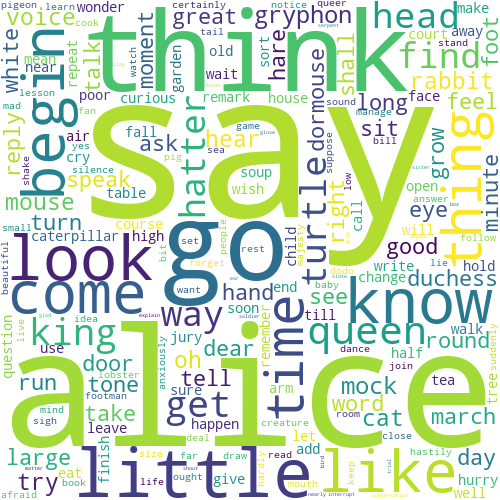

In [14]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, background_color="white").generate_from_frequencies(freq_cleaned)
wc.to_image()